# NBA Head-To-Head

**Goal**: Let's make two models, one that predicts home points, and another that predicts away points. Use same input data for now, but different outputs.

## Data

In [ ]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguegamelog, teamestimatedmetrics, leaguedashplayerstats, boxscoretraditionalv2

# ----------------------------------
# Step 1: Pull Game Logs + Team Stats
# ----------------------------------

def get_game_logs_for_season(season: str, season_type: str = "Regular Season"):
    print(f"Fetching game logs for {season}...")
    games = leaguegamelog.LeagueGameLog(season=season, season_type_all_star=season_type)
    df = games.get_data_frames()[0]
    df["Season"] = season
    return df

def get_team_metrics_for_season(season: str):
    print(f"Fetching team metrics for {season}...")
    metrics = teamestimatedmetrics.TeamEstimatedMetrics(season=season)
    df = metrics.get_data_frames()[0]
    df["Season"] = season
    return df

def pull_all_game_and_team_data(start_year=2015, end_year=2025):
    seasons = [f"{year}-{str(year+1)[-2:]}" for year in range(start_year, end_year + 1)]
    all_game_logs = []
    all_team_metrics = []

    for season in seasons:
        try:
            game_log = get_game_logs_for_season(season)
            team_metrics = get_team_metrics_for_season(season)
            all_game_logs.append(game_log)
            all_team_metrics.append(team_metrics)
            print(f"Completed season {season}")
            time.sleep(1.5)  # basic rate limit protection
        except Exception as e:
            print(f"Error pulling season {season}: {e}")
            time.sleep(5)

    games_df = pd.concat([df for df in all_game_logs if not df.empty], ignore_index=True)
    teams_df = pd.concat([df for df in all_team_metrics if not df.empty], ignore_index=True)

    return games_df, teams_df

# ----------------------------------
# Step 2: Create Game-Level Dataset
# ----------------------------------

def create_game_level_data(game_logs):
    games = []
    grouped = game_logs.groupby("GAME_ID")

    for game_id, group in grouped:
        if len(group) != 2:
            continue

        home_row = group[group["MATCHUP"].str.contains("vs.")]
        away_row = group[group["MATCHUP"].str.contains("@")]

        if home_row.empty or away_row.empty:
            continue

        game_data = {
            "GameID": game_id,
            "Season": group["Season"].iloc[0],
            "GameDate": group["GAME_DATE"].iloc[0],
            "HomeTeam": home_row["TEAM_NAME"].values[0],
            "AwayTeam": away_row["TEAM_NAME"].values[0],
            "HomePTS": home_row["PTS"].values[0],
            "AwayPTS": away_row["PTS"].values[0],
            "TotalPoints": home_row["PTS"].values[0] + away_row["PTS"].values[0]
        }

        games.append(game_data)

    return pd.DataFrame(games)

def merge_team_metrics(game_df, team_metrics_df):
    merged = pd.merge(
        game_df,
        team_metrics_df.add_prefix("Home_"),
        left_on=["HomeTeam", "Season"],
        right_on=["Home_TEAM_NAME", "Home_Season"],
        how="left"
    )

    merged = pd.merge(
        merged,
        team_metrics_df.add_prefix("Away_"),
        left_on=["AwayTeam", "Season"],
        right_on=["Away_TEAM_NAME", "Away_Season"],
        how="left"
    )

    return merged
    
# ----------------------------------
# Step 4: Add Rest Days / Back-to-Back Flags
# ----------------------------------

def compute_rest_days(game_logs):
    game_logs["GAME_DATE"] = pd.to_datetime(game_logs["GAME_DATE"])
    game_logs = game_logs.sort_values(["TEAM_NAME", "GAME_DATE"])
    game_logs["Prev_Game_Date"] = game_logs.groupby("TEAM_NAME")["GAME_DATE"].shift(1)
    game_logs["Rest_Days"] = (game_logs["GAME_DATE"] - game_logs["Prev_Game_Date"]).dt.days
    game_logs["BackToBack"] = (game_logs["Rest_Days"] == 1).astype(int)
    return game_logs

def merge_rest_b2b(merged_games, game_logs):
    home_rest = game_logs.add_prefix("Home_")
    merged_games['GameDate'] = pd.to_datetime(merged_games['GameDate'])
    merged = pd.merge(
        merged_games,
        home_rest[["Home_TEAM_NAME", "Home_GAME_DATE", "Home_Rest_Days", "Home_BackToBack"]],
        left_on=["HomeTeam", "GameDate"],
        right_on=["Home_TEAM_NAME", "Home_GAME_DATE"],
        how="left"
    )

    away_rest = game_logs.add_prefix("Away_")
    merged = pd.merge(
        merged,
        away_rest[["Away_TEAM_NAME", "Away_GAME_DATE", "Away_Rest_Days", "Away_BackToBack"]],
        left_on=["AwayTeam", "GameDate"],
        right_on=["Away_TEAM_NAME", "Away_GAME_DATE"],
        how="left"
    )

    return merged
# ----------------------------------
# Main Execution
# ----------------------------------
# Step 1
game_logs_df, team_metrics_df = pull_all_game_and_team_data()

Fetching game logs for 2015-16...
Fetching team metrics for 2015-16...
Completed season 2015-16
Fetching game logs for 2016-17...
Fetching team metrics for 2016-17...
Completed season 2016-17
Fetching game logs for 2017-18...
Fetching team metrics for 2017-18...
Completed season 2017-18
Fetching game logs for 2018-19...
Fetching team metrics for 2018-19...
Completed season 2018-19
Fetching game logs for 2019-20...
Fetching team metrics for 2019-20...
Completed season 2019-20
Fetching game logs for 2020-21...
Fetching team metrics for 2020-21...
Completed season 2020-21
Fetching game logs for 2021-22...
Fetching team metrics for 2021-22...
Completed season 2021-22
Fetching game logs for 2022-23...
Fetching team metrics for 2022-23...
Completed season 2022-23
Fetching game logs for 2023-24...
Fetching team metrics for 2023-24...
Completed season 2023-24
Fetching game logs for 2024-25...
Fetching team metrics for 2024-25...
Completed season 2024-25
Fetching game logs for 2025-26...
Fetchi

In [2]:
# Step 2
merged_games = merge_team_metrics(create_game_level_data(game_logs_df), team_metrics_df)

# Step 4
game_logs_df = compute_rest_days(game_logs_df)
merged_games = merge_rest_b2b(merged_games, game_logs_df)

### Rolling Features

For some features I'm just curious about...

I saw that one issue is just the spread of values in predicted points is a problem. So what if we encode the lagged standard deviation of point values? Could help with that issue.

One other thing is lagging the actual points scored diff to show if their performance is increasing/decreasing. This ... is a much higher risk of data leakage than my standard deviation idea though so I'm not sure how I feel.

In [48]:
df_eng = merged_games.copy()
df_eng['Home_PTS_Std_3'] = df_eng.groupby('HomeTeam')['HomePTS'].transform(
    lambda x: x.shift().rolling(window=3).std()
)
df_eng['Away_PTS_Std_3'] = df_eng.groupby('AwayTeam')['AwayPTS'].transform(
    lambda x: x.shift().rolling(window=3).std()
)
df_eng['Home_PTS_Trend'] = df_eng.groupby('HomeTeam')['HomePTS'].transform(
    lambda x: x.shift(1).rolling(5).mean() - x.shift(6).rolling(5).mean()
)
df_eng['Away_PTS_Trend'] = df_eng.groupby('AwayTeam')['AwayPTS'].transform(
    lambda x: x.shift(1).rolling(5).mean() - x.shift(6).rolling(5).mean()
)

In [49]:
df_eng.to_parquet("data/nba_starter_data.parquet", index=False)

### Feature Selection

In [50]:
import pandas as pd

df = pd.read_parquet("data/nba_starter_data.parquet")
display(df.head())

,GameID,Season,GameDate,HomeTeam,AwayTeam,HomePTS,AwayPTS,TotalPoints,Home_TEAM_NAME_x,Home_TEAM_ID,...,Home_Rest_Days,Home_BackToBack,Away_TEAM_NAME_y,Away_GAME_DATE,Away_Rest_Days,Away_BackToBack,Home_PTS_Std_3,Away_PTS_Std_3,Home_PTS_Trend,Away_PTS_Trend
0,0021500001,2015-16,2015-10-27,Atlanta Hawks,Detroit Pistons,94,106,200,Atlanta Hawks,1610612737,...,NaN,0,Detroit Pistons,2015-10-27,NaN,0,NaN,NaN,NaN,NaN
1,0021500002,2015-16,2015-10-27,Chicago Bulls,Cleveland Cavaliers,97,95,192,Chicago Bulls,1610612741,...,NaN,0,Cleveland Cavaliers,2015-10-27,NaN,0,NaN,NaN,NaN,NaN
2,0021500003,2015-16,2015-10-27,Golden State Warriors,New Orleans Pelicans,111,95,206,Golden State Warriors,1610612744,...,NaN,0,New Orleans Pelicans,2015-10-27,NaN,0,NaN,NaN,NaN,NaN
3,0021500004,2015-16,2015-10-28,Orlando Magic,Washington Wizards,87,88,175,Orlando Magic,1610612753,...,NaN,0,Washington Wizards,2015-10-28,NaN,0,NaN,NaN,NaN,NaN
4,0021500005,2015-16,2015-10-28,Boston Celtics,Philadelphia 76ers,112,95,207,Boston Celtics,1610612738,...,NaN,0,Philadelphia 76ers,2015-10-28,NaN,0,NaN,NaN,NaN,NaN


In [51]:
numeric_df = df.select_dtypes(include=['number'])
display(numeric_df.head())

,HomePTS,AwayPTS,TotalPoints,Home_TEAM_ID,Home_GP,Home_W,Home_L,Home_W_PCT,Home_MIN,Home_E_OFF_RATING,...,Away_E_TM_TOV_PCT_RANK,Away_E_PACE_RANK,Home_Rest_Days,Home_BackToBack,Away_Rest_Days,Away_BackToBack,Home_PTS_Std_3,Away_PTS_Std_3,Home_PTS_Trend,Away_PTS_Trend
0,94,106,200,1610612737,82,48,34,0.585,3966.0,103.0,...,8,20,NaN,0,NaN,0,NaN,NaN,NaN,NaN
1,97,95,192,1610612741,82,42,40,0.512,3981.0,102.1,...,13,28,NaN,0,NaN,0,NaN,NaN,NaN,NaN
2,111,95,206,1610612744,82,73,9,0.890,3976.0,112.5,...,4,11,NaN,0,NaN,0,NaN,NaN,NaN,NaN
3,87,88,175,1610612753,82,35,47,0.427,3981.0,102.6,...,15,5,NaN,0,NaN,0,NaN,NaN,NaN,NaN
4,112,95,207,1610612738,82,48,34,0.585,3956.0,103.9,...,29,6,NaN,0,NaN,0,NaN,NaN,NaN,NaN


In [52]:
corr_mat = numeric_df.corr()
home_pts_corr = corr_mat["HomePTS"].drop(['AwayPTS', 'TotalPoints']).abs().sort_values(ascending=False)
away_pts_corr = corr_mat["AwayPTS"].drop(['HomePTS', 'TotalPoints']).abs().sort_values(ascending=False)

Never mind these ideas are not that great, but we'll save them for later.

In [54]:
home_pts_corr['Home_PTS_Trend']

np.float64(0.030220658533775185)

Let's make a side-by-side correlation heatmap. This'll be helpful as an artifact for the paper.

Note that we're doing some ad-hoc analysis of correlation instead of things like PCA because I want to keep interpretability. Could also use LASSO regression to do this but it's a bit trickier because then it gets questionable during tuning.

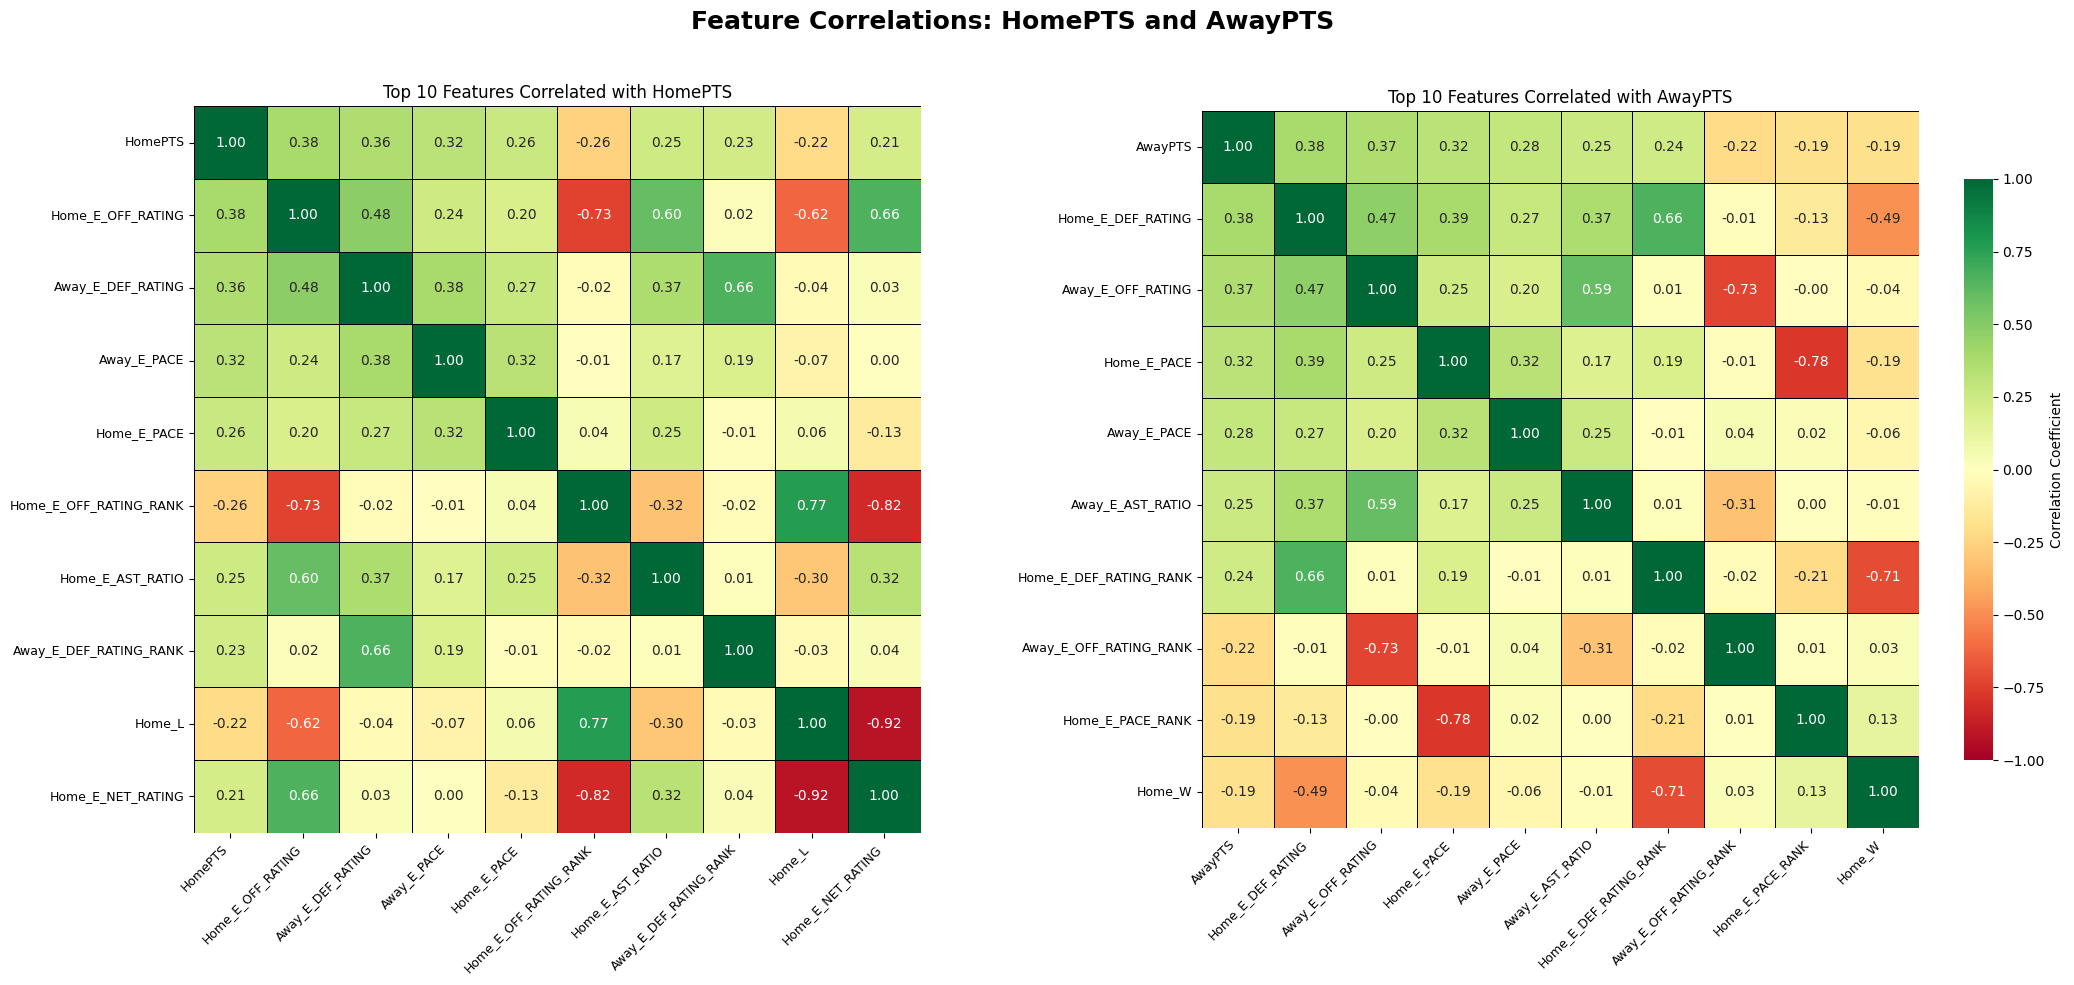

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

top10_home_feats = home_pts_corr.head(10).index.tolist()
top10_away_feats = away_pts_corr.head(10).index.tolist()

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# LEFT HEATMAP: HomePTS
home_matrix = df[top10_home_feats].corr()
sns.heatmap(home_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='black',
            cbar=False,
            ax=axes[0])

axes[0].set_title('Top 10 Features Correlated with HomePTS')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# RIGHT HEATMAP: AwayPTS
away_matrix = df[top10_away_feats].corr()
sns.heatmap(away_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='black',
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
            ax=axes[1])

axes[1].set_title('Top 10 Features Correlated with AwayPTS')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=9)

# Overall title
plt.suptitle('Feature Correlations: HomePTS and AwayPTS', 
             fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('correlation_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

Based on this heatmap, let's use the following for home points. Note that the assist ratios and rating ranks are pretty correlated features so we'll decline to use them. Statistics is an art so to speak.

1. Home offensive rating (`Home_E_OFF_RATING`)
2. Away defensive rating (`Away_E_DEF_RATING`)
3. Away pace (`Away_E_PACE`)
4. Home pace (`Home_E_PACE`)

We'll also include the home & away back to back indicator values. We'll not use the rest days due to the correlation being low.

6. Home back-to-back indicator (`Home_BackToBack`)
7. Away back-to-back indicator (`Away_BackToBack`)

Then we can literally just flip home and away above to obtain the set of features for away points, funnily enough!

Now let's add some rolling averages for features above.

In [58]:
df_selected = df[['GameID', 'GameDate', 'HomeTeam', 'AwayTeam', 'HomePTS', 'AwayPTS', 'Home_E_OFF_RATING', 'Away_E_OFF_RATING', 'Home_E_DEF_RATING', 'Away_E_DEF_RATING', 'Home_E_PACE', 'Away_E_PACE', 'Home_BackToBack', 'Away_BackToBack']]
display(df_selected.head())

,GameID,GameDate,HomeTeam,AwayTeam,HomePTS,AwayPTS,Home_E_OFF_RATING,Away_E_OFF_RATING,Home_E_DEF_RATING,Away_E_DEF_RATING,Home_E_PACE,Away_E_PACE,Home_BackToBack,Away_BackToBack
0,0021500001,2015-10-27,Atlanta Hawks,Detroit Pistons,94,106,103.0,103.3,99.3,102.6,99.1,97.8,0,0
1,0021500002,2015-10-27,Chicago Bulls,Cleveland Cavaliers,97,95,102.1,108.1,103.6,101.9,98.4,95.7,0,0
2,0021500003,2015-10-27,Golden State Warriors,New Orleans Pelicans,111,95,112.5,103.2,102.0,107.0,101.1,99.0,0,0
3,0021500004,2015-10-28,Orlando Magic,Washington Wizards,87,88,102.6,102.9,104.2,103.4,98.4,100.7,0,0
4,0021500005,2015-10-28,Boston Celtics,Philadelphia 76ers,112,95,103.9,96.6,100.7,106.8,101.2,100.2,0,0


In [81]:
def Add_Rolling_Averages(df, team_prefix, window):
    df[f'{team_prefix}_Rolling_PTS_Mean_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}PTS'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).mean()
    )
    df[f'{team_prefix}_Rolling_PTS_Std_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}PTS'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).std()
    )
    df[f'{team_prefix}_Rolling_OffRating_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}_E_OFF_RATING'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).mean()
    )
    df[f'{team_prefix}_Rolling_DefRating_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}_E_DEF_RATING'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).mean()
    )
    df[f'{team_prefix}_Rolling_Pace_{window}'] = df.groupby(f'{team_prefix}Team')[f'{team_prefix}_E_PACE'].transform(
        lambda x: x.shift().rolling(window, min_periods=1).mean()
    )

    return df

df_rolling = df_selected.copy()
df_rolling = Add_Rolling_Averages(df_rolling, 'Home', 5)
df_rolling = Add_Rolling_Averages(df_rolling, 'Away', 5)
df_rolling = Add_Rolling_Averages(df_rolling, 'Home', 10)
df_rolling = Add_Rolling_Averages(df_rolling, 'Away', 10)

display(df_rolling.head())

,GameID,GameDate,HomeTeam,AwayTeam,HomePTS,AwayPTS,Home_E_OFF_RATING,Away_E_OFF_RATING,Home_E_DEF_RATING,Away_E_DEF_RATING,...,Home_Rolling_PTS_Mean_10,Home_Rolling_PTS_Std_10,Home_Rolling_OffRating_10,Home_Rolling_DefRating_10,Home_Rolling_Pace_10,Away_Rolling_PTS_Mean_10,Away_Rolling_PTS_Std_10,Away_Rolling_OffRating_10,Away_Rolling_DefRating_10,Away_Rolling_Pace_10
0,0021500001,2015-10-27,Atlanta Hawks,Detroit Pistons,94,106,103.0,103.3,99.3,102.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0021500002,2015-10-27,Chicago Bulls,Cleveland Cavaliers,97,95,102.1,108.1,103.6,101.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0021500003,2015-10-27,Golden State Warriors,New Orleans Pelicans,111,95,112.5,103.2,102.0,107.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0021500004,2015-10-28,Orlando Magic,Washington Wizards,87,88,102.6,102.9,104.2,103.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0021500005,2015-10-28,Boston Celtics,Philadelphia 76ers,112,95,103.9,96.6,100.7,106.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's wrap up and export now!

In [82]:
df_rolling.to_parquet("data/nba_rolling_features.parquet", index=False)

## Model Features

In [123]:
df = pd.read_parquet("data/nba_rolling_features.parquet")
df = df.drop(['HomeTeam', 'AwayTeam', 'GameID'], axis=1)

# Parse dates
df["GameDate"] = pd.to_datetime(df["GameDate"])

Also, let's add some more interactions. The ones that are interesting to explicitly call out:
1. Pace interaction: Home pace times Away pace
2. Offensive/Defensive Ratio: Home offensive rating / Away defensive rating, and vice versa

In [124]:
df['PaceInteraction'] = df['Home_E_PACE'] * df['Away_E_PACE']
df['Home_Off_Away_Def'] = df['Home_E_OFF_RATING'] / df['Away_E_DEF_RATING']
df['Away_Off_Home_Def'] = df['Away_E_OFF_RATING'] / df['Home_E_DEF_RATING']

First let's set the columns per model.

In [125]:
home_model_features = ["Home_E_OFF_RATING", "Away_E_DEF_RATING", "Away_E_PACE", "Home_E_PACE", "Home_BackToBack", "Away_BackToBack", "PaceInteraction", "Home_Off_Away_Def"]
home_model_features += [col for col in df.columns if 
    col.startswith('Home_Rolling_OffRating_')
    or col.startswith('Away_Rolling_DefRating_')
    or col.startswith('Home_Rolling_Pace_') 
    or col.startswith('Away_Rolling_Pace_')
    or col.startswith('Home_Rolling_PTS_')
]

home_model_features

['Home_E_OFF_RATING',
 'Away_E_DEF_RATING',
 'Away_E_PACE',
 'Home_E_PACE',
 'Home_BackToBack',
 'Away_BackToBack',
 'PaceInteraction',
 'Home_Off_Away_Def',
 'Home_Rolling_PTS_Mean_5',
 'Home_Rolling_PTS_Std_5',
 'Home_Rolling_OffRating_5',
 'Home_Rolling_Pace_5',
 'Away_Rolling_DefRating_5',
 'Away_Rolling_Pace_5',
 'Home_Rolling_PTS_Mean_10',
 'Home_Rolling_PTS_Std_10',
 'Home_Rolling_OffRating_10',
 'Home_Rolling_Pace_10',
 'Away_Rolling_DefRating_10',
 'Away_Rolling_Pace_10']

In [126]:
away_model_features = ["Away_E_OFF_RATING", "Home_E_DEF_RATING", "Away_E_PACE", "Home_E_PACE", "Home_BackToBack", "Away_BackToBack", "PaceInteraction", "Away_Off_Home_Def"]
away_model_features += [col for col in df.columns if 
    col.startswith('Away_Rolling_OffRating_')
    or col.startswith('Home_Rolling_DefRating_')
    or col.startswith('Home_Rolling_Pace_') 
    or col.startswith('Away_Rolling_Pace_')
    or col.startswith('Away_Rolling_PTS_')
]

away_model_features

['Away_E_OFF_RATING',
 'Home_E_DEF_RATING',
 'Away_E_PACE',
 'Home_E_PACE',
 'Home_BackToBack',
 'Away_BackToBack',
 'PaceInteraction',
 'Away_Off_Home_Def',
 'Home_Rolling_DefRating_5',
 'Home_Rolling_Pace_5',
 'Away_Rolling_PTS_Mean_5',
 'Away_Rolling_PTS_Std_5',
 'Away_Rolling_OffRating_5',
 'Away_Rolling_Pace_5',
 'Home_Rolling_DefRating_10',
 'Home_Rolling_Pace_10',
 'Away_Rolling_PTS_Mean_10',
 'Away_Rolling_PTS_Std_10',
 'Away_Rolling_OffRating_10',
 'Away_Rolling_Pace_10']

## Model Training

In [127]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

First let's do the train-test split and scaling. It'll require dropping the NA values from the rolling features though. Which also means that this model won't be very effective at the beginning of a completely new season.

In [101]:
cutoff_date = pd.to_datetime("2024-10-01")

train_df = df[df["GameDate"] < cutoff_date]
test_df = df[df["GameDate"] >= cutoff_date]

print(f"Train size: {len(train_df)} games")
print(f"Test size: {len(test_df)} games")

# Drop NA values; inputting mean causes data leakage in rolling averages
train_df = train_df.dropna()
test_df = test_df.dropna()

# Split HomePTS and AwayPTS
y_train = train_df[["HomePTS", "AwayPTS"]]
X_train = train_df.drop(columns=["HomePTS", "AwayPTS", "GameDate"])

y_test = test_df[["HomePTS", "AwayPTS"]]
X_test = test_df.drop(columns=["HomePTS", "AwayPTS", "GameDate"])

# Scale features
scaled_data = {
    'HomePTS': {},
    'AwayPTS': {}
}
home_scaler = StandardScaler()
scaled_data['HomePTS']['X_train'] = home_scaler.fit_transform(X_train[home_model_features])
scaled_data['HomePTS']['X_test'] = home_scaler.transform(X_test[home_model_features])

away_scaler = StandardScaler()
scaled_data['AwayPTS']['X_train'] = away_scaler.fit_transform(X_train[away_model_features])
scaled_data['AwayPTS']['X_test'] = away_scaler.transform(X_test[away_model_features])


Train size: 10749 games
Test size: 1283 games


In [130]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.025, random_state=5105),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.025, random_state=5105),
}

# Train and evaluate; save in the nested dict
results = []
predictions = {model: {} for model in models.keys()}

for name, model in models.items():
    for point in ["HomePTS", "AwayPTS"]:
        if point == "HomePTS":
            model_features = home_model_features
        else:
            model_features = away_model_features
        
        print(f"Training {name} for {point}...")

        X_train_scaled = scaled_data[point]['X_train']
        X_test_scaled = scaled_data[point]['X_test']
        model.fit(X_train_scaled, y_train[point])
        y_pred = model.predict(X_test_scaled)

        mae = mean_absolute_error(y_test[point], y_pred)
        rmse = root_mean_squared_error(y_test[point], y_pred)
        r2 = r2_score(y_test[point], y_pred)

        results.append({
            "Model": name,
            "Predicting": point,
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "R2 Score": round(r2, 4)
        })

        predictions[name][point] = y_pred  # store predictions separately
    
    # Calculate winner prediction accuracy (after both HomePTS and AwayPTS are predicted). It'll be kind of a funky store but it'll show up properly still.
    home_pred = predictions[name]["HomePTS"]
    away_pred = predictions[name]["AwayPTS"]
    home_true = y_test["HomePTS"].values
    away_true = y_test["AwayPTS"].values

    pred_winner = home_pred > away_pred
    true_winner = home_true > away_true
    winner_acc = np.mean(pred_winner == true_winner)

    results[-1]["Winner Accuracy"] = round(winner_acc, 4)

results_df = pd.DataFrame(results)
print("\nFinal Model Evaluation on 2024–2025 Season:")
print(results_df)

# Save to CSV
results_df.to_csv("predictions/final_model_results_2024_2025.csv", index=False)

# Save Predictions for Each Model
for model_name, preds in predictions.items():
    test_results = test_df.copy()
    test_results[model_name.replace(" ", "_") + "_HomePTS"] = preds['HomePTS']
    test_results[model_name.replace(" ", "_") + "_AwayPTS"] = preds['AwayPTS']
    save_filename = "".join(["predictions/", model_name.replace(" ", "_").lower(), "_predictions_v3.csv"])
    test_results.to_csv(save_filename, index=False)
    print(f"Saved {model_name} predictions to {save_filename}")

Training Linear Regression for HomePTS...
Training Linear Regression for AwayPTS...
Training Lasso Regression for HomePTS...
Training Lasso Regression for AwayPTS...
Training XGBoost for HomePTS...
Training XGBoost for AwayPTS...
Training LightGBM for HomePTS...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3806
[LightGBM] [Info] Number of data points in the train set: 10677, number of used features: 20
[LightGBM] [Info] Start training from score 111.050576
Training LightGBM for AwayPTS...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000348 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3810
[LightGBM] [Info] Number of data points in the train set: 10677, number of used features: 20
[LightGBM] [Info] Start training from score 108.779620

Final Model Eva

d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Let's sample 100 games from the test data and show the predictions across the three models.

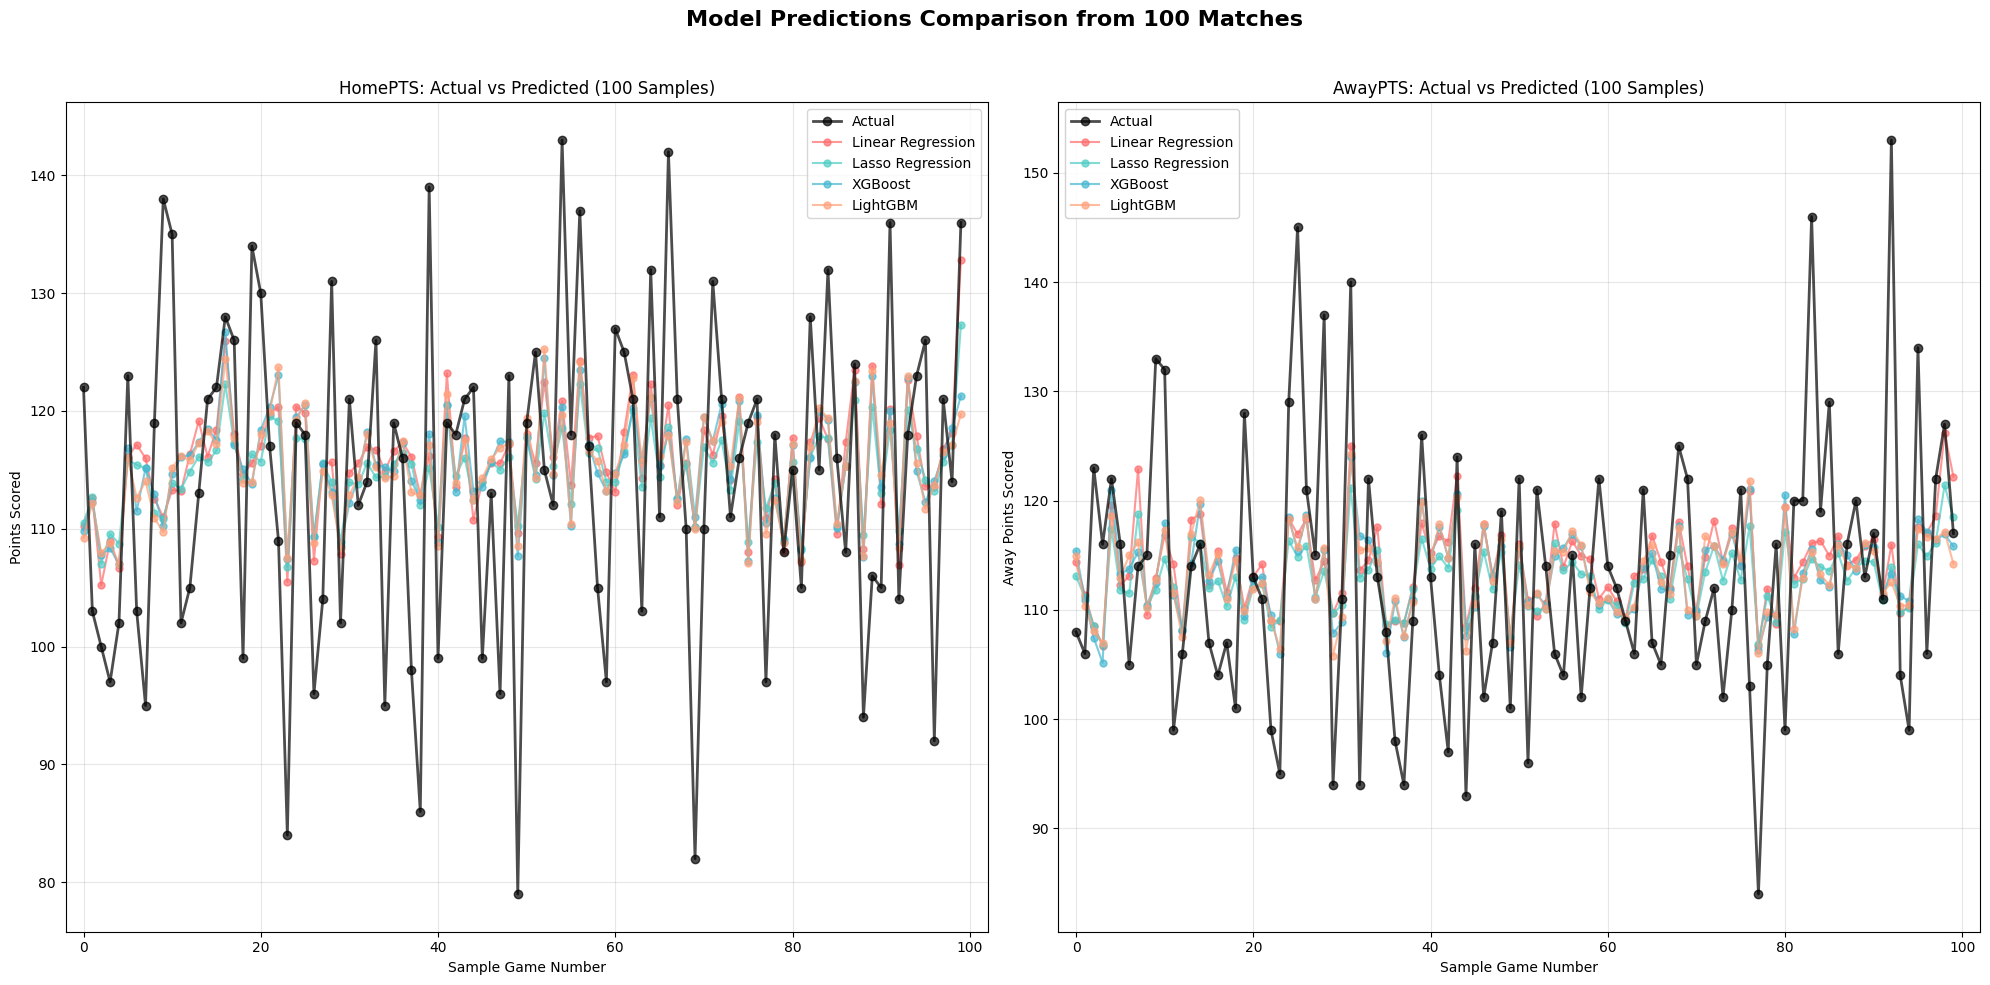

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sampled_games = 100

sample_indices = np.random.choice(len(test_df), size=sampled_games, replace=False)
sample_indices = np.sort(sample_indices)  # Sort for better visualization

actual_home = test_df['HomePTS'].iloc[sample_indices].values
actual_away = test_df['AwayPTS'].iloc[sample_indices].values

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
x = np.arange(sampled_games)

### HomePTS
ax1 = axes[0]

# Plot actual values as baseline
ax1.plot(x, actual_home, 'o-', color='black', linewidth=2, markersize=6, 
            label='Actual', alpha=0.7, zorder=10)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for idx, (model_name, preds) in enumerate(predictions.items()):
    home_pred = preds['HomePTS'][sample_indices]
    color = colors[idx % len(colors)]
    
    ax1.plot(x, home_pred, 'o-', 
            color=color, linewidth=1.5, markersize=5,
            label=model_name, alpha=0.7)

ax1.set_xlabel('Sample Game Number')
ax1.set_ylabel('Points Scored')
ax1.set_title('HomePTS: Actual vs Predicted (100 Samples)')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2, sampled_games + 2)

### AwayPTS
ax2 = axes[1]

# Plot actual values as baseline
ax2.plot(x, actual_away, 'o-', color='black', linewidth=2, markersize=6,
            label='Actual', alpha=0.7, zorder=10)

# Plot predictions for each model
for idx, (model_name, preds) in enumerate(predictions.items()):
    away_pred = preds['AwayPTS'][sample_indices]
    color = colors[idx % len(colors)]
    
    ax2.plot(x, away_pred, 'o-',
            color=color, linewidth=1.5, markersize=5,
            label=model_name, alpha=0.7)

ax2.set_xlabel('Sample Game Number')
ax2.set_ylabel('Away Points Scored')
ax2.set_title(f'AwayPTS: Actual vs Predicted ({sampled_games} Samples)')
ax2.legend(loc='best', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, sampled_games + 2)

# Overall title
plt.suptitle(f'Model Predictions Comparison from {sampled_games} Matches', 
                fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [134]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import TimeSeriesSplit

models = {
    "Lasso": Lasso(),
    "XGBoost": XGBRegressor(random_state=5105, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=5105, n_jobs=-1)
}

search_space = {
    "Lasso": {
        'alpha': Real(0.1, 1.0, prior='log-uniform')
    },
    "XGBoost": {
        'n_estimators': Integer(50, 250),
        'learning_rate': Real(0.005, 0.05, prior='log-uniform'),
        'max_depth': Integer(3, 10),
        'reg_alpha': Real(0.0, 1.0, prior='uniform'),
        'reg_lambda': Real(0.0, 1.0, prior='uniform')
    },
    "LightGBM": {
        'n_estimators': Integer(50, 250),
        'learning_rate': Real(0.005, 0.05, prior='log-uniform'),
        'max_depth': Integer(3, 10),
        'reg_alpha': Real(0.0, 1.0, prior='uniform'),
        'reg_lambda': Real(0.0, 1.0, prior='uniform')
    }
}

tuning_results = {model: {} for model in models.keys()}

for model_name in ["Lasso", "XGBoost", "LightGBM"]:
    for point in ['HomePTS', 'AwayPTS']:
        opt = BayesSearchCV(
            estimator=models[model_name],
            search_spaces=search_space[model_name],
            n_iter=100,
            scoring='neg_root_mean_squared_error',
            cv=TimeSeriesSplit(n_splits=3),  # 3-fold time series split CV
            n_jobs=-1,
            random_state=5105
        )
        opt.fit(scaled_data[point]['X_train'], y_train[point])
        test_score = opt.score(scaled_data[point]['X_test'], y_test[point])
        preds = opt.predict(scaled_data[point]['X_test'])
        r2 = r2_score(y_test[point], preds)
        # Log the performance
        print(f"Best parameters for {model_name} predicting {point}: {opt.best_params_} with RMSE: {-opt.best_score_:.4f}, Test RMSE = {-test_score:.2f}, Test R2 = {r2:.4f}\n")

        tuning_results[model_name][point] = opt

Best parameters for Lasso predicting HomePTS: OrderedDict({'alpha': 0.8367308190687731}) with RMSE: 11.5371, Test RMSE = 11.33, Test R2 = 0.1936

Best parameters for Lasso predicting AwayPTS: OrderedDict({'alpha': 0.6672866021563219}) with RMSE: 11.5548, Test RMSE = 11.52, Test R2 = 0.1872

Best parameters for XGBoost predicting HomePTS: OrderedDict({'learning_rate': 0.049999999999999996, 'max_depth': 3, 'n_estimators': 50, 'reg_alpha': 1.0, 'reg_lambda': 0.6426059062457503}) with RMSE: 11.6475, Test RMSE = 11.40, Test R2 = 0.1835

Best parameters for XGBoost predicting AwayPTS: OrderedDict({'learning_rate': 0.049999999999999996, 'max_depth': 3, 'n_estimators': 50, 'reg_alpha': 1.0, 'reg_lambda': 0.0}) with RMSE: 11.6337, Test RMSE = 11.55, Test R2 = 0.1823

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3806
[LightGBM] [Info] Number of data po

d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3810
[LightGBM] [Info] Number of data points in the train set: 10677, number of used features: 20
[LightGBM] [Info] Start training from score 108.779620
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Okay so funnily enough my base guess was pretty good, and sometimes better than these. But I will take a few of these for myself, particularly the LASSO results and the max depth and the learning rates.

In [140]:
from sklearn.base import clone

# Define models
models = {
    "Linear Regression": {
        "HomePTS": LinearRegression(),
        "AwayPTS": LinearRegression()
    },
    "Lasso Regression": {
        "HomePTS": clone(tuning_results["Lasso"]["HomePTS"].best_estimator_),
        "AwayPTS": clone(tuning_results["Lasso"]["AwayPTS"].best_estimator_),
    },
    "XGBoost": {
        "HomePTS": XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.025, random_state=5105),
        "AwayPTS": XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.025, random_state=5105),
    },
    "LightGBM": {
        "HomePTS": LGBMRegressor(n_estimators=200, max_depth=3, learning_rate=0.025, random_state=5105),
        "AwayPTS": LGBMRegressor(n_estimators=200, max_depth=3, learning_rate=0.025, random_state=5105),
    },
}

# Train and evaluate; save in the nested dict
results = []
predictions = {model: {} for model in models.keys()}

for name, model in models.items():
    for point in ["HomePTS", "AwayPTS"]:
        print(f"Training {name} for {point}...")

        X_train_scaled = scaled_data[point]['X_train']
        X_test_scaled = scaled_data[point]['X_test']
        model[point].fit(X_train_scaled, y_train[point])
        y_pred = model[point].predict(X_test_scaled)

        mae = mean_absolute_error(y_test[point], y_pred)
        rmse = root_mean_squared_error(y_test[point], y_pred)
        r2 = r2_score(y_test[point], y_pred)

        results.append({
            "Model": name,
            "Predicting": point,
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "R2 Score": round(r2, 4)
        })

        predictions[name][point] = y_pred  # store predictions separately
    
    # Calculate winner prediction accuracy (after both HomePTS and AwayPTS are predicted). It'll be kind of a funky store but it'll show up properly still.
    home_pred = predictions[name]["HomePTS"]
    away_pred = predictions[name]["AwayPTS"]
    home_true = y_test["HomePTS"].values
    away_true = y_test["AwayPTS"].values

    pred_winner = home_pred > away_pred
    true_winner = home_true > away_true
    winner_acc = np.mean(pred_winner == true_winner)

    results[-1]["Winner Accuracy"] = round(winner_acc, 4)

results_df = pd.DataFrame(results)
print("\nFinal Model Evaluation on 2024–2025 Season:")
print(results_df)

Training Linear Regression for HomePTS...
Training Linear Regression for AwayPTS...
Training Lasso Regression for HomePTS...
Training Lasso Regression for AwayPTS...
Training XGBoost for HomePTS...
Training XGBoost for AwayPTS...
Training LightGBM for HomePTS...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000356 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3806
[LightGBM] [Info] Number of data points in the train set: 10677, number of used features: 20
[LightGBM] [Info] Start training from score 111.050576
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


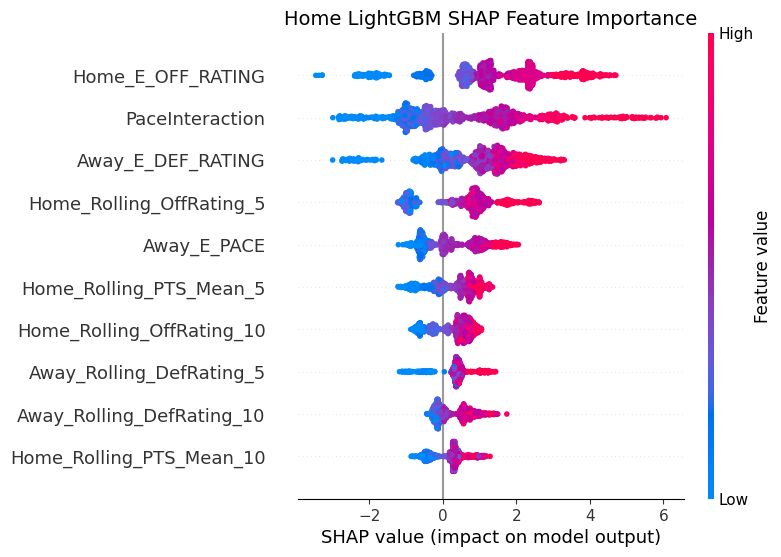

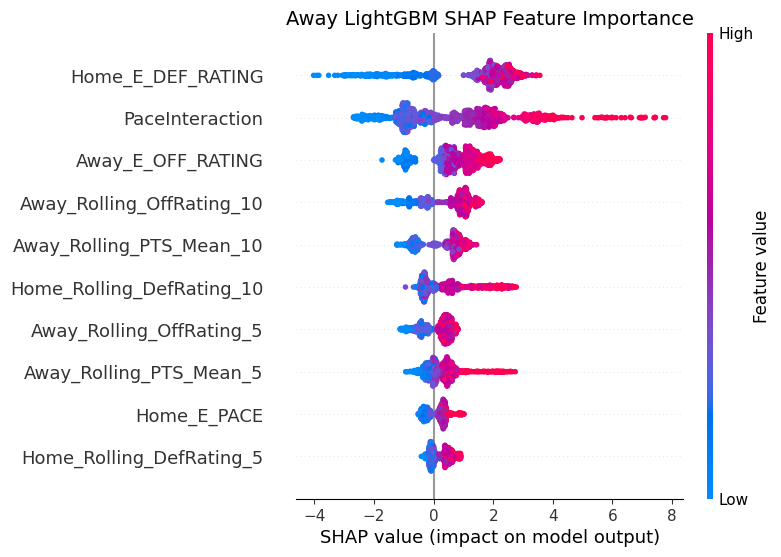

In [146]:
import shap

import matplotlib.pyplot as plt

lgbm_home_model = models["LightGBM"]["HomePTS"]
lgbm_away_model = models["LightGBM"]["AwayPTS"]

# Create SHAP explainers for both models
explainer_home = shap.TreeExplainer(lgbm_home_model)
explainer_away = shap.TreeExplainer(lgbm_away_model)
shap_values_home = explainer_home.shap_values(scaled_data['HomePTS']['X_test'])
shap_values_away = explainer_away.shap_values(scaled_data['AwayPTS']['X_test'])

# HomePTS SHAP summary plot
shap.summary_plot(shap_values_home, 
                  scaled_data['HomePTS']['X_test'], 
                  feature_names=home_model_features,
                  show=False,
                  max_display=10)
plt.title('Home LightGBM SHAP Feature Importance', fontsize=14)
plt.show()

# AwayPTS SHAP summary plot
shap.summary_plot(shap_values_away, 
                  scaled_data['AwayPTS']['X_test'], 
                  feature_names=away_model_features,
                  show=False,
                  max_display=10)
plt.title('Away LightGBM SHAP Feature Importance', fontsize=14)
plt.show()

In [145]:
away_model_features

['Away_E_OFF_RATING',
 'Home_E_DEF_RATING',
 'Away_E_PACE',
 'Home_E_PACE',
 'Home_BackToBack',
 'Away_BackToBack',
 'PaceInteraction',
 'Away_Off_Home_Def',
 'Home_Rolling_DefRating_5',
 'Home_Rolling_Pace_5',
 'Away_Rolling_PTS_Mean_5',
 'Away_Rolling_PTS_Std_5',
 'Away_Rolling_OffRating_5',
 'Away_Rolling_Pace_5',
 'Home_Rolling_DefRating_10',
 'Home_Rolling_Pace_10',
 'Away_Rolling_PTS_Mean_10',
 'Away_Rolling_PTS_Std_10',
 'Away_Rolling_OffRating_10',
 'Away_Rolling_Pace_10']

### Save Model

In [143]:
import pickle

with open('models/lightgbm_away_scaler.pkl', 'wb') as f:
    pickle.dump(home_scaler, f)

with open('models/lightgbm_home_scaler.pkl', 'wb') as f:
    pickle.dump(away_scaler, f)

best_model_home_filename = 'models/lightgbm_home_model.pkl'
with open(best_model_home_filename, 'wb') as f:
    pickle.dump(models["LightGBM"]["HomePTS"], f)

best_model_away_filename = 'models/lightgbm_away_model.pkl'
with open(best_model_away_filename, 'wb') as f:
    pickle.dump(models["LightGBM"]["AwayPTS"], f)

### Save Dummy Data (for Front-end Dev)

In [144]:
X_test[home_model_features].to_parquet("model_test_input/home_model_test_data.parquet", index=False)
X_test[away_model_features].to_parquet("model_test_input/away_model_test_data.parquet", index=False)

In [10]:
test_df = pd.read_parquet("model_test_input/home_model_test_data.parquet")
test_df.head()

,Home_E_OFF_RATING,Away_E_DEF_RATING,Away_E_PACE,Home_E_PACE,Home_BackToBack,Away_BackToBack,Home_Rolling_PTS_Mean_5,Home_Rolling_PTS_Std_5,Home_Rolling_OffRating_5,Home_Rolling_Pace_5,Away_Rolling_DefRating_5,Away_Rolling_Pace_5,Home_Rolling_PTS_Mean_10,Home_Rolling_PTS_Std_10,Home_Rolling_OffRating_10,Home_Rolling_Pace_10,Away_Rolling_DefRating_10,Away_Rolling_Pace_10
0,107.2,110.7,100.2,102.1,0,0,106.0,7.035624,107.8,101.6,111.20,98.80,108.4,6.963396,107.8,101.6,111.20,98.80
1,108.3,117.4,99.3,104.8,0,0,118.0,10.271319,111.5,101.1,112.70,103.20,117.2,10.840254,111.5,101.1,112.70,103.20
2,120.2,113.3,99.3,99.6,0,0,119.4,14.328294,115.7,100.4,112.34,99.94,118.3,11.225467,115.7,100.4,112.22,100.02
3,111.5,110.6,99.9,101.6,0,0,113.8,8.043631,107.7,102.5,109.90,101.40,111.5,7.735201,107.7,102.5,109.90,101.40
4,104.2,116.7,102.6,101.0,0,0,124.6,17.271364,112.3,103.6,113.60,103.20,124.1,13.535550,112.3,103.6,113.60,103.20


## Classification

Out of curiosity, I want to try just training a normal classifier and seeing how it performs, using the feature set proposed. Not spending a lot of time on this so not including in final report.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [46]:
cutoff_date = df["GameDate"].quantile(0.8)

train_df = df[df["GameDate"] < cutoff_date].copy()
test_df = df[df["GameDate"] >= cutoff_date].copy()

print(f"Train size: {len(train_df)} games")
print(f"Test size: {len(test_df)} games")

# Prepare binary target for winner: 1 if Home wins, 0 if Away wins
train_df["HomeWin"] = (train_df["HomePTS"] > train_df["AwayPTS"]).astype(int)
test_df["HomeWin"] = (test_df["HomePTS"] > test_df["AwayPTS"]).astype(int)

y_train = train_df["HomeWin"]
y_test = test_df["HomeWin"]

# Use the same features as before, or select a subset if desired
X_train = train_df[home_model_features + away_model_features]
X_test = test_df[home_model_features + away_model_features]

# Drop NA values; imputing mean causes data leakage in rolling averages
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=5105),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.025, random_state=5105, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.025, random_state=5105),
}

results = []
predictions = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    y_proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "ROC AUC": round(auc, 4) if auc is not None else None
    })

    predictions[name] = y_pred

results_df = pd.DataFrame(results)
print("\nFinal Classification Model Evaluation on 2024–2025 Season:")
print(results_df)

Train size: 9622 games
Test size: 2410 games
Training Logistic Regression...
Training XGBoost...
Training LightGBM...


d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:26:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 5464, number of negative: 4086
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000643 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6703
[LightGBM] [Info] Number of data points in the train set: 9550, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.572147 -> initscore=0.290615
[LightGBM] [Info] Start training from score 0.290615

Final Classification Model Evaluation on 2024–2025 Season:
                 Model  Accuracy  ROC AUC
0  Logistic Regression    0.6929   0.7610
1              XGBoost    0.6797   0.7368
2             LightGBM    0.6759   0.7433


d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Development\NBA_OVER_UNDER_TOTAL\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
